In [ ]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
!pip install keras-unet

In [ ]:
from keras_unet.models import custom_unet
from matplotlib import pyplot as plt
from keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import numpy as np


In [ ]:
#
# 1. DATA
#

from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True
)

images = [f for f in os.listdir("images") if f.startswith("Abyssinian")]

!wget https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/images.npz
!wget https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/masks.npz

--2026-03-01 20:11:31--  https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/images.npz
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/refs/heads/main/images.npz [following]
--2026-03-01 20:11:32--  https://raw.githubusercontent.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/refs/heads/main/images.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9832112 (9.4M) [application/octet-stream]
Saving to: ‘images.npz.1’

images.npz.1        100%[===================>]   9.38M  --.-KB/s    in 0.02s   

2026-03-01 20:11:33 (526 MB/s

In [ ]:
images = np.load('images.npz')['images'][:,:,:,0] # we only need one channel since it's grayscale
masks = np.load('masks.npz')['masks']

In [ ]:
#
# PAD IMAGES to 320x320
#
X_train = images[0:170]
y_train = masks[0:170]
X_train = np.pad(X_train[..., None], ((0,0),(10,10),(10,10),(0,0)))
y_train = np.pad(y_train[..., None], ((0,0),(10,10),(10,10),(0,0)))

X_test = images[170:]
y_test = masks[170:]
X_test = np.pad(X_test[..., None], ((0,0),(10,10),(10,10),(0,0)))
y_test = np.pad(y_test[..., None], ((0,0),(10,10),(10,10),(0,0)))

In [ ]:
#
# 2. NETWORK
#
model = custom_unet(
    input_shape=(320, 320, 1), dropout = 0.05
)
model.compile(loss='binary_crossentropy')

In [ ]:
#
# 3. TRAIN
#
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.1, epochs=50, callbacks=[checkpoint, early_stopping])

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.2988 - val_loss: 1.3511
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.3090 - val_loss: 3.8783
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.2660 - val_loss: 3.3492
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2450 - val_loss: 2.3971
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.2350 - val_loss: 1.1337
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2241 - val_loss: 0.9393
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.2150 - val_loss: 0.7932
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1963 - val_loss: 0.4783
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1931 - val_loss: 0.3555
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1746 - val_loss: 0.2220
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1811 - val_loss: 0.2023
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1571 - val_loss: 0.6847
E

In [ ]:
#
# 4. PREDICT
#
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step


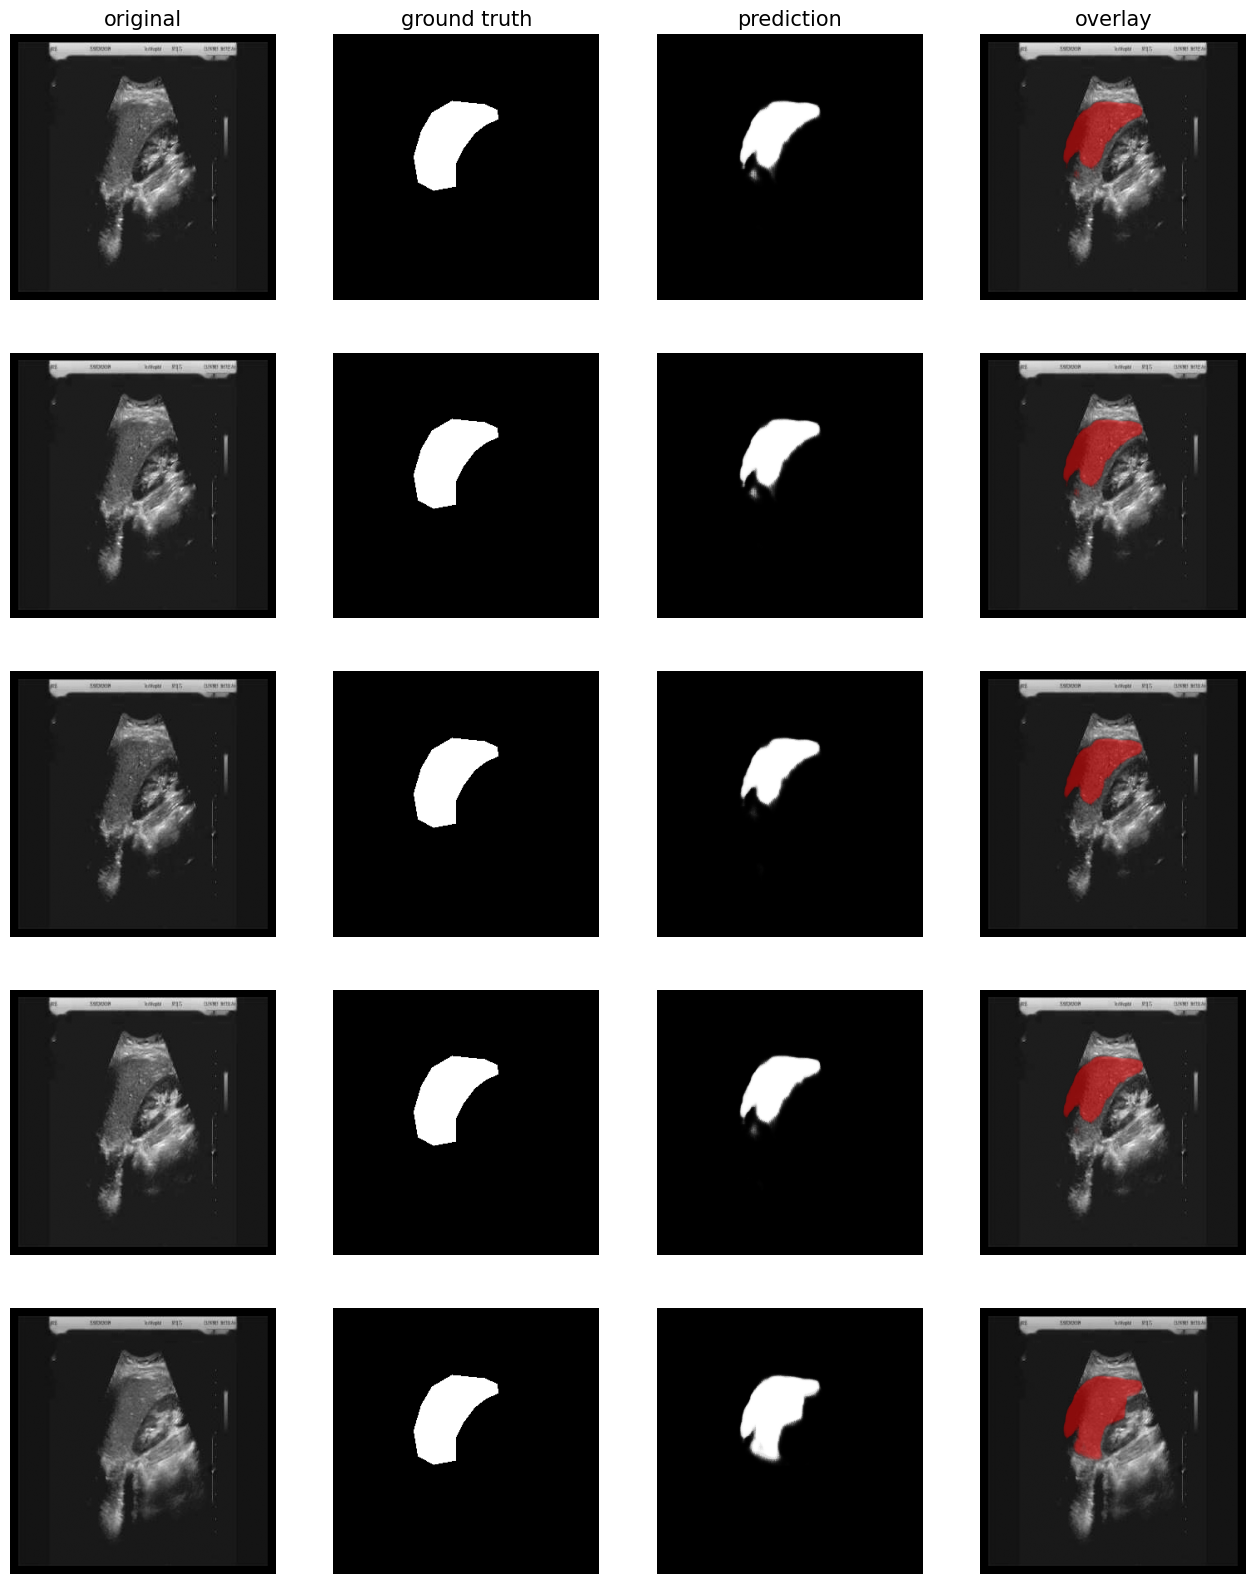

In [ ]:
from keras_unet.utils import plot_imgs

plot_imgs(org_imgs=X_test, mask_imgs=y_test, pred_imgs=y_pred, nm_img_to_plot=5)